## Agent Based Modelling

In [1]:
pip install mesa

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mesa]
Note: you may need to restart the kernel to use updated packages.


In [2]:
pip install networkx

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 45.1 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [3]:
import numpy as np
import pandas as pd


In [4]:
df = pd.read_csv("Mammary_data_response_1e8.csv")
df_T11 = df[df['Cell_Line'] == 'T11']
df_T11_ICI = df_T11[df_T11['Mouse_treatment']!='no_treatment']
df_T11_ICI

,Unnamed: 0,Dendritic_quanTIseq,NK_quanTIseq,T.CD8_quanTIseq,Tregs_quanTIseq,Mouse_treatment,Condition,Timepoint,ICB_study,GSM_ID,Cell_Line,Cancer_type,Study_ID
166,SRX5100724,0.001480,0.000810,0.000054,0.000361,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554847,T11,"Mammary cancer, NOS",GSE124821
169,SRX5100642,0.002127,0.001080,0.000074,0.000376,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554850,T11,"Mammary cancer, NOS",GSE124821
171,SRX5100638,0.005433,0.001761,0.000051,0.000530,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554852,T11,"Mammary cancer, NOS",GSE124821
172,SRX5100632,0.007120,0.002415,0.000192,0.000578,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554853,T11,"Mammary cancer, NOS",GSE124821
173,SRX5100675,0.005026,0.001591,0.000043,0.000476,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554854,T11,"Mammary cancer, NOS",GSE124821
175,SRX5100859,0.001926,0.000846,0.000024,0.000324,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554856,T11,"Mammary cancer, NOS",GSE124821
177,SRX5100857,0.004220,0.001382,0.000040,0.000431,antiPD1; antiCTLA4;,Apobec_day3,day3,R,GSM3554858,T11,"Mammary cancer, NOS",GSE124821
180,SRX5100867,0.001831,0.000895,0.000002,0.000430,antiPD1; antiCTLA4;,Apobec_end,end,R,GSM3554861,T11,"Mammary cancer, NOS",GSE124821
186,SRX5100790,0.003833,0.001607,0.000578,0.000508,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554883,T11,"Mammary cancer, NOS",GSE124821
187,SRX5100789,0.005915,0.001772,0.000768,0.000565,antiPD1; antiCTLA4;,UV_day7,day7,R,GSM3554884,T11,"Mammary cancer, NOS",GSE124821


### this is the code for preparing the scatter graph of the data 

In [5]:
#treatment with mutagen
mutagen_Ds = []
mutagen_NKs = []
mutagen_T8s = []
mutagen_Tregs = []

scatter_mutagen_Ds = []
scatter_mutagen_NKs = []
scatter_mutagen_Tregs = []
scatter_mutagen_T8s = []
scatter_mutagen_times = []


quanTIseq_cols = ["Dendritic_quanTIseq","NK_quanTIseq","T.CD8_quanTIseq","Tregs_quanTIseq"]

time_points = ["day3","day7","end"]


for day in time_points:
    day_df = df_T11_ICI[df_T11_ICI['Condition'].str.contains('_'+day)]
    print("")
    print(f"Number of replicates {len(day_df)}")
    averages = day_df.filter(items=quanTIseq_cols).mean()
    print(averages)
    print(type(day_df.filter(items=quanTIseq_cols).mean()))
    mutagen_Ds.append(averages["Dendritic_quanTIseq"])
    mutagen_NKs.append(averages["NK_quanTIseq"])
    mutagen_T8s.append(averages["T.CD8_quanTIseq"])
    mutagen_Tregs.append(averages["Tregs_quanTIseq"])
    mutagen_total = sum(averages)
    print(mutagen_total)
    if "day" in day:
        day = float(day.split("day")[1])
        if day in [3.0,7.0]:
            for i in day_df['Dendritic_quanTIseq']:
                scatter_mutagen_Ds.append(i)
                scatter_mutagen_times.append(day)
            for i in day_df["NK_quanTIseq"]:
                scatter_mutagen_NKs.append(i)
            for i in day_df["Tregs_quanTIseq"]:
                scatter_mutagen_Tregs.append(i)
            for i in day_df["T.CD8_quanTIseq"]:
                scatter_mutagen_T8s.append(i)


Number of replicates 7
Dendritic_quanTIseq    0.004187
NK_quanTIseq           0.001479
T.CD8_quanTIseq        0.000074
Tregs_quanTIseq        0.000443
dtype: float64
<class 'pandas.Series'>
0.006182992517142857

Number of replicates 8
Dendritic_quanTIseq    0.004660
NK_quanTIseq           0.001701
T.CD8_quanTIseq        0.000798
Tregs_quanTIseq        0.000610
dtype: float64
<class 'pandas.Series'>
0.0077687861

Number of replicates 9
Dendritic_quanTIseq    0.002484
NK_quanTIseq           0.001149
T.CD8_quanTIseq        0.000036
Tregs_quanTIseq        0.000457
dtype: float64
<class 'pandas.Series'>
0.004125642369866667


## Agent Based Modelling - spatial component + stochasticity 

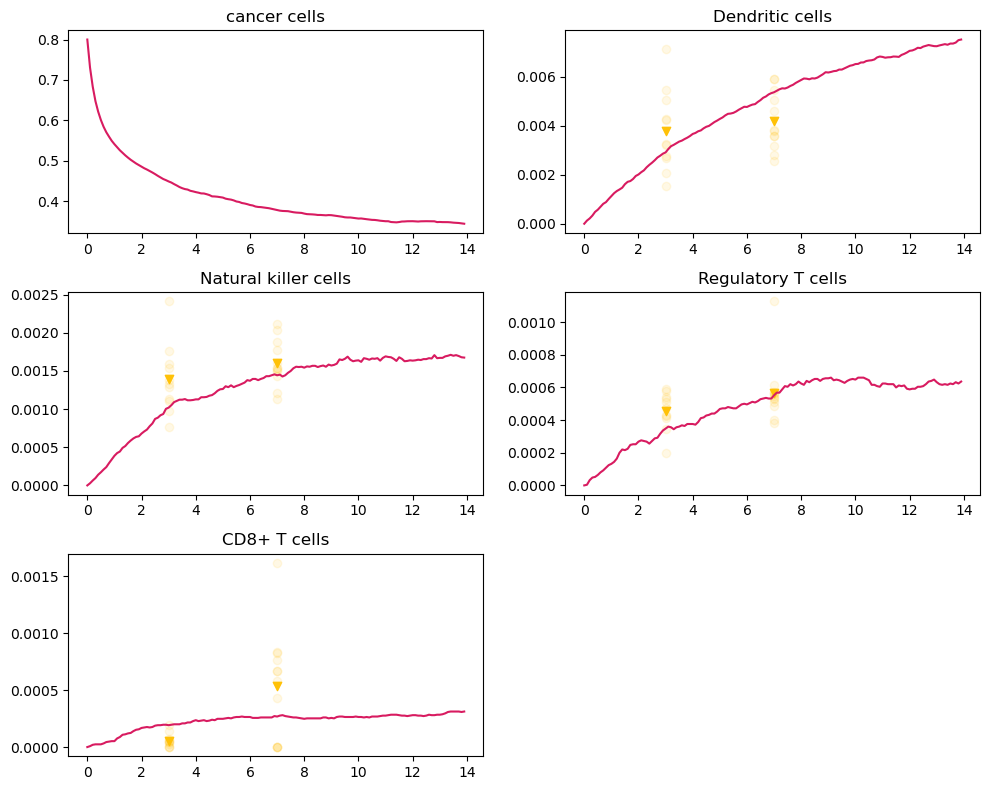

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# colour
c1 = (216/255, 27/255, 96/255)   # pink for the ABM 
c3 = (255/255, 193/255, 7/255)   # yellow for the data 

# params
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8
}

grid_size = 500
days = 14
dt = 0.01  
steps = int(days / dt)
total_sites = grid_size**2

def run_spatial_abm():
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, grid_size, grid_size))
    # initial seeding 
    grids[0] = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    
    results = {k: [] for k in ['C', 'D', 'N', 'Tr', 'T8']}
    time_axis = []

    for step in range(steps):
        props = np.sum(grids, axis=(1, 2)) / total_sites
        C, D, N, Tr, T8 = props

        # cancer
        growth_p = p['lambda_C'] * C * dt
        kill_p = (((p['lambda_C']*C*C)/p['C_M']) + p['eta_8'] * T8 + p['eta_N'] * N + p['d_C']) * dt
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0

        if step % 10 == 0:
            for i, key in enumerate(['C', 'D', 'N', 'Tr', 'T8']):
                results[key].append(props[i]) # the state data for each of the variables is stored every 10 steps
            time_axis.append(step * dt)

    return time_axis, results

# simulate
t_abm, y_abm = run_spatial_abm()

# plot
fig, ax = plt.subplots(3, 2, figsize=(10, 8))

# scatter data
def get_scatter(df, col):
    times = df_T11_ICI['Timepoint'].map({'day3': 3.0, 'day7': 7.0}).values
    vals = df_T11_ICI[col].values
    # 'v' marker means 
    m3 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day3'][col].mean()
    m7 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day7'][col].mean()
    return times, vals, [3.0, 7.0], [m3, m7]

# cancer
ax[0,0].plot(t_abm, y_abm['C'], color=c1)
ax[0,0].set_title('cancer cells')

# dendritic
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Dendritic_quanTIseq")
ax[0,1].plot(t_abm, y_abm['D'], color=c1)
ax[0,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[0,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[0,1].set_title('Dendritic cells')

# NK
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "NK_quanTIseq")
ax[1,0].plot(t_abm, y_abm['N'], color=c1)
ax[1,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,0].set_title('Natural killer cells')

# Tregs
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Tregs_quanTIseq")
ax[1,1].plot(t_abm, y_abm['Tr'], color=c1)
ax[1,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,1].set_title('Regulatory T cells')

# CD8
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "T.CD8_quanTIseq")
ax[2,0].plot(t_abm, y_abm['T8'], color=c1)
ax[2,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[2,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[2,0].set_title('CD8+ T cells')

# extra plot
ax[2,1].set_visible(False)

plt.tight_layout()
plt.show()



## turning this into an animation file 

In [26]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation, FFMpegWriter

def run_spatial_abm_with_history(grid_size, steps, p, dt):
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, grid_size, grid_size))
    grids[0] = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    
    total_sites = grid_size**2
    history = [] # This will store the frames for the animation

    for step in range(steps):
        props = np.sum(grids, axis=(1, 2)) / total_sites
        C, D, N, Tr, T8 = props
        # cancer
        growth_p = p['lambda_C'] * C * dt
        kill_p = (((p['lambda_C']*C*C)/p['C_M']) + p['eta_8'] * T8 + p['eta_N'] * N + p['d_C']) * dt
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0

        
        # save snapshot every 5 steps for animation
        i# --- Capture Frame for Animation ---
        if step % 5 == 0:
            # Create a blank grid
            viz_frame = np.zeros((grid_size, grid_size))
            
            # Assign unique values for each cell type
            viz_frame[grids[1] == 1] = 1 # Dendritic (Orange)
            viz_frame[grids[3] == 1] = 2 # T-Regs (Purple)
            viz_frame[grids[2] == 1] = 3 # NK Cells (Green)
            viz_frame[grids[4] == 1] = 4 # CD8+ T-Cells (Blue)
            viz_frame[grids[0] == 1] = 5 # Cancer Cells (Red) - Layered last to stay visible
            
            history.append(viz_frame)

    return history

In [79]:
import matplotlib.patches as mpatches
from matplotlib.animation import FuncAnimation, FFMpegWriter

def save_abm_animation(history, filename):
    fig, ax = plt.subplots(figsize=(12, 8)) 
    
    # 0:Black, 1:Orange(D), 2:Purple(Tr), 3:Green(N), 4:Blue(T8), 5:Red(C)
    colors = ['black', '#f39c12', '#9b59b6', '#2ecc71', '#3498db', '#e74c3c']
    from matplotlib.colors import ListedColormap
    cmap = ListedColormap(colors)
    
    # vmin=0, vmax=5 ensures the colors don't switch if a cell type goes extinct
    im = ax.imshow(history[0], cmap=cmap, interpolation='nearest', vmin=0, vmax=5)
    ax.set_title(f'{filename}', fontsize=14)
    plt.axis('off')

    legend_items = [
        mpatches.Patch(color='#e74c3c', label='Cancer Cells'),
        mpatches.Patch(color='#3498db', label='CD8+ T-Cells'),
        mpatches.Patch(color='#2ecc71', label='NK Cells'),
        mpatches.Patch(color='#f39c12', label='Dendritic Cells'),
        mpatches.Patch(color='#9b59b6', label='T-Regs (Suppressors)')
    ]
    
    ax.legend(handles=legend_items, bbox_to_anchor=(1.05, 1), loc='upper left')

    def update(frame_idx):
        im.set_array(history[frame_idx])
        return [im]

    ani = FuncAnimation(fig, update, frames=len(history), interval=50, blit=True)
    
    writer = FFMpegWriter(fps=20, bitrate=2000)
    ani.save(filename, writer=writer)
    plt.show()

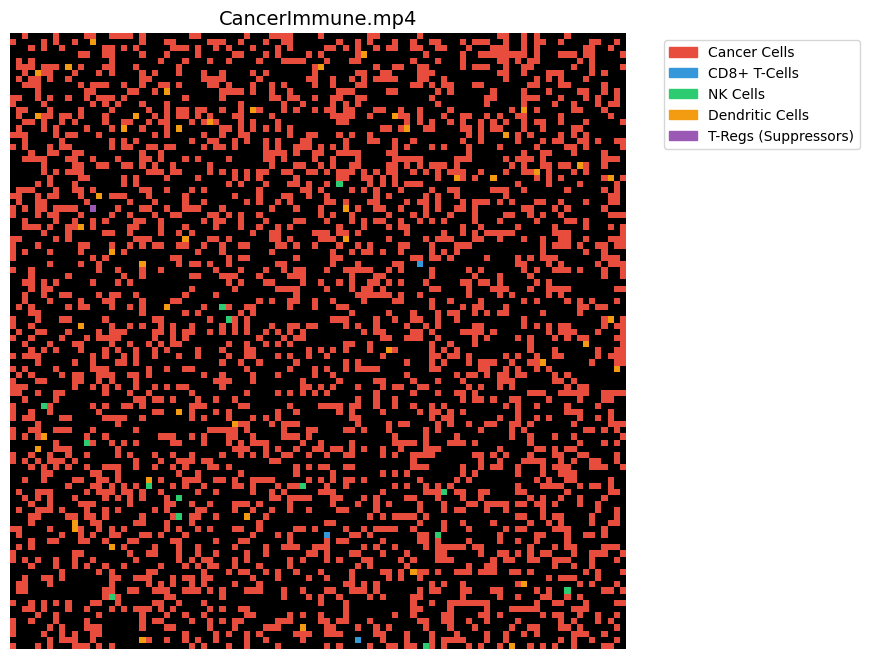

In [80]:
# 1. Run the simulation
grid_size = 100 # made the grid size smaller so you can actually see the animation 
history_data = run_spatial_abm_with_history(grid_size, steps, p, dt)

# 2. Save to file
save_abm_animation(history_data, "CancerImmune.mp4")

## adding a Chemotaxis rule to the ABM so that immune cells move towards the cancer cells 

In [81]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from matplotlib import colors
from scipy.ndimage import gaussian_filter


In [82]:
import numpy as np
from scipy.ndimage import gaussian_filter

def run_spatial_abm_chemotaxis(grid_size, steps, p, dt):
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, grid_size, grid_size))
    grids[0] = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    
    grid_history = [] 

    for step in range(steps):
        # 1. SIGNAL GENERATION
        # Cancer cells "secrete" a signal that spreads
        signal = gaussian_filter(grids[0], sigma=3.0) 

        # 2. CHEMOTAXIS MOVEMENT
        # NK (2) and CD8+ (4) move toward the signal gradient
        for layer_idx in [2, 4]:
            if np.sum(grids[layer_idx]) > 0:
                # Calculate the direction of the steepest increase in signal
                grad_y, grad_x = np.gradient(signal)
                
                # Move cells: if grad is positive, move +1; if negative, move -1
                move_y = np.sign(grad_y).astype(int)
                move_x = np.sign(grad_x).astype(int)
                
                # Create a temporary grid for moved cells
                new_layer = np.zeros_like(grids[layer_idx])
                
                # Vectorized movement: Shift the whole grid based on the local gradient
                # We only move a fraction of cells (p_move) to keep it realistic
                p_move = 0.2 
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                stay_mask = (grids[layer_idx] == 1) & (~move_mask)
                
                # Apply movement using indices (simplified for speed)
                y_idx, x_idx = np.where(move_mask)
                new_y = np.clip(y_idx + move_y[y_idx, x_idx], 0, grid_size-1)
                new_x = np.clip(x_idx + move_x[y_idx, x_idx], 0, grid_size-1)
                
                new_layer[stay_mask] = 1
                new_layer[new_y, new_x] = 1
                grids[layer_idx] = new_layer

        # 3. REACTION STEP
        props = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        C, D, N, Tr, T8 = props
        # cancer
        growth_p = p['lambda_C'] * C * dt
        kill_p = (((p['lambda_C']*C*C)/p['C_M']) + p['eta_8'] * T8 + p['eta_N'] * N + p['d_C']) * dt
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0

        # 4. CAPTURE HISTORY
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[1] == 1] = 1 # Orange
            viz_frame[grids[3] == 1] = 2 # Purple
            viz_frame[grids[2] == 1] = 3 # Green
            viz_frame[grids[4] == 1] = 4 # Blue
            viz_frame[grids[0] == 1] = 5 # Red
            
            # The critical line that was missing:
            grid_history.append(viz_frame.copy())
            
    return grid_history

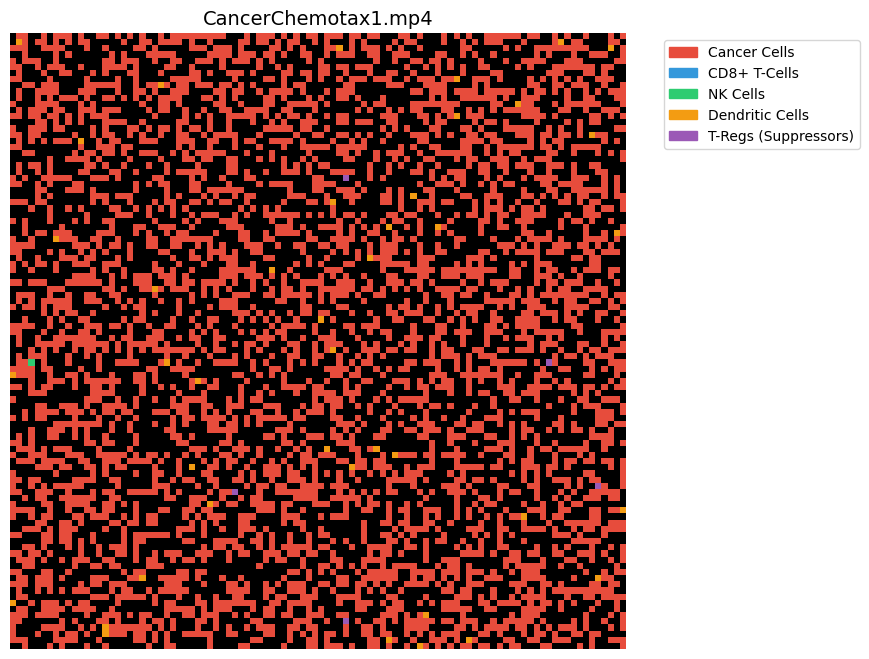

In [83]:
history_data = run_spatial_abm_chemotaxis(grid_size, steps, p, dt)

save_abm_animation(history_data, "CancerChemotax1.mp4")

## going to make the cancer cells just cluster together some more like a solid cancer 

In [84]:
import numpy as np
from scipy.ndimage import gaussian_filter
from scipy.signal import convolve2d

def run_abm_clustering(grid_size, steps, p, dt):
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, grid_size, grid_size))
    
    # INITIAL SEEDING: Instead of random noise, place a small "seed" in the center
    mid = grid_size // 2
    grids[0, mid-3:mid+4, mid-3:mid+4] = np.random.choice([0, 1], size=(7, 7), p=[0.2, 0.8])
    
    grid_history = []
    # Kernel to check 8 neighbors (Moore neighborhood)
    kernel = np.array([[1, 1, 1],
                       [1, 0, 1],
                       [1, 1, 1]])

    for step in range(steps):
        # 1. TUMOR CLUSTERING LOGIC (Local Growth)
        # Count how many cancer neighbors each pixel has
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        
        # Growth only happens next to existing cancer (Clustering)
        # Probability increases if you have more neighbors (up to a point)
        #growth_p = p['lambda_C'] * (cancer_neighbors / 8) * dt
        
        # ------------------------
        # 2. Strict Growth: Only grow if you have at least 1 neighbor 
        # This prevents random 'islands' from forming.
        can_grow = (grids[0] == 0) & (cancer_neighbors >= 1)
        growth_p = p['lambda_C'] * (cancer_neighbors / 8) * dt
        grids[0][can_grow & (np.random.rand(grid_size, grid_size) < growth_p)] = 1
        
        # 3. High Adhesion: Isolated cells are deleted immediately
        # This forces the simulation to focus only on the main mass.
        is_isolated = (grids[0] == 1) & (cancer_neighbors < 1)
        grids[0][is_isolated] = 0
        # ----------------
        
        # 2. GLOBAL FEEDBACK & IMMUNE KILLING
        props = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        C, D, N, Tr, T8 = props
        
        # Kill probability (Standard logic)
        kill_p = (((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt

        # Apply Cancer Updates
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < kill_p)] = 0

        # 3. CHEMOTAXIS (Immune cells scent the tumor)
        signal = gaussian_filter(grids[0], sigma=4.0) # Signal from the solid mass
        for layer_idx in [2, 4]: # NK and T8
            if np.sum(grids[layer_idx]) > 0:
                grad_y, grad_x = np.gradient(signal)
                move_y, move_x = np.sign(grad_y).astype(int), np.sign(grad_x).astype(int)
                
                # Only move 30% of cells per step for smoothness
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < 0.3)
                stay_mask = (grids[layer_idx] == 1) & (~move_mask)
                
                y_idx, x_idx = np.where(move_mask)
                new_y = np.clip(y_idx + move_y[y_idx, x_idx], 0, grid_size-1)
                new_x = np.clip(x_idx + move_x[y_idx, x_idx], 0, grid_size-1)
                
                temp_layer = np.zeros_like(grids[layer_idx])
                temp_layer[stay_mask] = 1
                temp_layer[new_y, new_x] = 1
                grids[layer_idx] = temp_layer

        # 4. IMMUNE DYNAMICS (Birth/Death of D, N, Tr, T8)
           # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0
        

        # 5. CAPTURE HISTORY FOR ANIMATION
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[1] == 1] = 1 # Orange (D)
            viz_frame[grids[3] == 1] = 2 # Purple (Tr)
            viz_frame[grids[2] == 1] = 3 # Green (N)
            viz_frame[grids[4] == 1] = 4 # Blue (T8)
            viz_frame[grids[0] == 1] = 5 # Red (C)
            grid_history.append(viz_frame.copy())

    return grid_history

In [85]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.animation import ArtistAnimation
import matplotlib.patches as mpatches

def save_abm_animation(history, filename, fps=20):
    if not history:
        print("Error: History is empty. Run simulation first.")
        return

    # 1. Setup figure and colors
    fig, ax = plt.subplots(figsize=(10, 8))
    # Colors: 0:Black, 1:Orange(D), 2:Purple(Tr), 3:Green(N), 4:Blue(T8), 5:Red(C)
    colors = ['black', '#f39c12', '#9b59b6', '#2ecc71', '#3498db', '#e74c3c']
    cmap = ListedColormap(colors)
    
    # 2. Add Legend (Permanent, not part of animation loop)
    legend_items = [
        mpatches.Patch(color='#e74c3c', label='Cancer Cells'),
        mpatches.Patch(color='#3498db', label='CD8+ T-Cells'),
        mpatches.Patch(color='#2ecc71', label='NK Cells'),
        mpatches.Patch(color='#f39c12', label='Dendritic Cells'),
        mpatches.Patch(color='#9b59b6', label='T-Regs (Suppressors)')
    ]
    ax.legend(handles=legend_items, bbox_to_anchor=(1.05, 1), loc='upper left', borderaxespad=0.)
    ax.axis('off')

    # 3. Create frames efficiently
    # We use ArtistAnimation for pre-computed history lists
    ims = []
    for frame_data in history:
        # add=True is key for performance here
        im = ax.imshow(frame_data, cmap=cmap, animated=True, vmin=0, vmax=5, interpolation='nearest')
        ims.append([im])

    # 4. Save the animation
    ani = ArtistAnimation(fig, ims, interval=1000/fps, blit=True, repeat_delay=1000)

    print(f"Saving to {filename}...")
    try:
        if filename.endswith('.mp4'):
            ani.save(filename, writer='ffmpeg', fps=fps, bitrate=2000)
        else:
            ani.save(filename, writer='pillow', fps=fps)
        print("Save successful.")
    except Exception as e:
        print(f"Ffmpeg failed, trying pillow (GIF)... Error: {e}")
        ani.save(filename.replace('.mp4', '.gif'), writer='pillow', fps=fps)
        print(f"Saved as GIF instead.")

    plt.close(fig) # Cleanup memory

In [86]:
history_data = run_abm_clustering(grid_size, steps, p, dt)
# 2. Check if data exists
print(f"Captured {len(history_data)} frames.")

# 3. Save animation
if len(history_data) > 0:
    save_abm_animation(history_data, "CancerSolid1.mp4",20)
else:
    print("Error: No history data to animate!")

Captured 280 frames.
Saving to CancerSolid1.mp4...
Save successful.


## Treg shielding 

In [94]:
def run_abm_shielded(grid_size, steps, p, dt):
    grids = np.zeros((5, grid_size, grid_size))
    mid = grid_size // 2
    grids[0, mid-3:mid+4, mid-3:mid+4] = 1 # Initial Tumor Seed
    
    grid_history = []
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for step in range(steps):
        # 1. NEIGHBOR COUNTS
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        treg_neighbors = convolve2d(grids[3], kernel, mode='same') # Presence of Shield

        # 2. CANCER GROWTH (Clustered)
        growth_p = p['lambda_C'] * ((cancer_neighbors / 8)) * dt
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # 3. THE SHIELDED KILL LOGIC
        # We calculate the base kill probability
        C, D, N, Tr, T8 = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        
        # SHIELDING FACTOR: If T-Regs are nearby, kill_p is divided by (1 + Treg_neighbors)
        # This means if a cancer cell is surrounded by 4 T-Regs, it's 5x harder to kill.
        shield_effect = 1.0 / (1.0 + p.get('shield_strength', 5.0) * treg_neighbors)
        
        kill_p_base = (((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt
        final_kill_p = kill_p_base * shield_effect
        
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < final_kill_p)] = 0

        # 4. CHEMOTAXIS (Including T-Regs heading to the tumor)
        signal = gaussian_filter(grids[0], sigma=4.0)
        # Move NK (2), T-Regs (3), and T8 (4)
        for layer_idx in [2, 3, 4]:
            if np.sum(grids[layer_idx]) > 0:
                grad_y, grad_x = np.gradient(signal)
                # T-Regs (3) are even more attracted to the signal (higher p_move)
                p_move = 0.5 if layer_idx == 3 else 0.2 
                
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                y_idx, x_idx = np.where(move_mask)
                
                # ... [Standard movement logic using move_y, move_x as before] ...
                # (Applying the shift and clipping to grid boundaries)
                # Note: Ensure you use the movement logic from the previous function here

        # 5. REACTION DYNAMICS (Birth/Death of Immune Cells)
        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0
        

        # 6. CAPTURE FOR ANIMATION
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[3] == 1] = 2 # Purple (Tr) - Shield
            viz_frame[grids[4] == 1] = 4 # Blue (T8) - Attackers
            viz_frame[grids[0] == 1] = 5 # Red (C) - Target
            grid_history.append(viz_frame.copy())

    return grid_history

In [95]:
history_data = run_abm_shielded(grid_size, steps, p, dt)

save_abm_animation(history_data, "CancerTREGSHIELD1.mp4")

Saving to CancerTREGSHIELD1.mp4...
Save successful.


## Necrotic centre 

In [96]:
def run_abm_necrotic(grid_size, steps, p, dt):
    grids = np.zeros((5, grid_size, grid_size))
    mid = grid_size // 2
    # Seed a slightly larger initial mass to speed up the process
    grids[0, mid-5:mid+6, mid-5:mid+6] = 1 
    
    grid_history = []
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for step in range(steps):
        # 1. NEIGHBORHOOD ANALYSIS
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        treg_neighbors = convolve2d(grids[3], kernel, mode='same')

        # 2. CANCER DYNAMICS
        # Proliferation (Outer Rim)
        growth_p = p['lambda_C'] * (cancer_neighbors / 8) * dt
        
        # Necrosis (The Core) - Cells with 8 neighbors die due to hypoxia
        # We use a small probability so the core doesn't vanish instantly
        is_buried = (grids[0] == 1) & (cancer_neighbors == 8)
        necrosis_p = 0.03 * dt 
        
        # Shielded Killing (The Periphery)
        C, D, N, Tr, T8 = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        shield_effect = 1.0 / (1.0 + p.get('shield_strength', 5.0) * treg_neighbors)
        kill_p = ((((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt) * shield_effect
        
        # Update Cancer Layer
        grids[0][(grids[0] == 0) & (np.random.rand(grid_size, grid_size) < growth_p)] = 1
        grids[0][(grids[0] == 1) & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        grids[0][is_buried & (np.random.rand(grid_size, grid_size) < necrosis_p)] = 0

        # 3. CHEMOTAXIS & IMMUNE MOVEMENT
        signal = gaussian_filter(grids[0], sigma=4.0)
        grad_y, grad_x = np.gradient(signal)
        
        for layer_idx in [2, 3, 4]: # NK, Tr, T8
            if np.sum(grids[layer_idx]) > 0:
                # T8 and NK move toward signal; Tr moves even more aggressively to shield
                p_move = 0.4 if layer_idx == 3 else 0.2
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                
                # Apply movement (Vectorized)
                y_idx, x_idx = np.where(move_mask)
                move_y, move_x = np.sign(grad_y).astype(int), np.sign(grad_x).astype(int)
                new_y = np.clip(y_idx + move_y[y_idx, x_idx], 0, grid_size-1)
                new_x = np.clip(x_idx + move_x[y_idx, x_idx], 0, grid_size-1)
                
                temp = np.zeros_like(grids[layer_idx])
                temp[(grids[layer_idx] == 1) & (~move_mask)] = 1
                temp[new_y, new_x] = 1
                grids[layer_idx] = temp

        # 4. IMMUNE REACTION (Birth/Death)
        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0
        

        # 5. CAPTURE HISTORY
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[3] == 1] = 2 # Purple Shield
            viz_frame[grids[4] == 1] = 4 # Blue Attackers
            viz_frame[grids[0] == 1] = 5 # Red Cancer
            # The gaps in the red center will naturally show as black (Necrosis)
            grid_history.append(viz_frame.copy())

    return grid_history

In [97]:
history_data = run_abm_necrotic(grid_size, steps, p, dt)

save_abm_animation(history_data, "CancerNecrotic1.mp4")

Saving to CancerNecrotic1.mp4...
Save successful.


## FINAL MODEL : solid mass with high adhesion, necrotic centre and chemotaxis and immune cells only kill when touching a cancer cell 

In [121]:
def run_abm_solid_mass(grid_size, steps, p, dt):
    grids = np.zeros((5, grid_size, grid_size))
    #mid = grid_size // 2
    # Start with a solid 4x4 block
    #grids[0, mid-2:mid+2, mid-2:mid+2] = 1 
    # Initial seeding: 80% of the grid starts as cancer : THIS IS NEWWW 
    grids[0] = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    
    grid_history = []
    # Moore neighborhood (8 neighbors)
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for step in range(steps):
        # 1. ANALYZE LOCAL DENSITY
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        treg_neighbors = convolve2d(grids[3], kernel, mode='same')

        # 2. SOLID TUMOR GROWTH RULES
        # A: Growth only at the boundary (must have at least 1 neighbor)
        # B: Growth probability is high to ensure a dense pack
        can_grow = (grids[0] == 0) & (cancer_neighbors >= 1)
        # We use a non-linear boost: the more neighbors, the more likely to fill gaps
        growth_p = p['lambda_C'] * (cancer_neighbors / 3) * dt 
        grids[0][can_grow & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # 3. HIGH ADHESION (The "Cleaning" Rule)
        # If a cell has 0 neighbors, it's a 'stray' and dies immediately
        is_stray = (grids[0] == 1) & (cancer_neighbors == 0)
        grids[0][is_stray] = 0

        # 4. NECROTIC CORE (Internal pressure)
        is_buried = (grids[0] == 1) & (cancer_neighbors == 8)
        # Low probability (0.01) keeps the core 'meaty' but eventually dead
        grids[0][is_buried & (np.random.rand(grid_size, grid_size) < 0.01 * dt)] = 0

        # 5. SHIELDED KILLING
        C, D, N, Tr, T8 = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        #shield_effect = 1.0 / (1.0 + p.get('shield_strength', 5.0) * treg_neighbors)
        kill_p = ((((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt) 
        
        # Immune cells can only kill if they are touching the cancer
        at_edge = (grids[0] == 1) & (cancer_neighbors < 8)
        grids[0][at_edge & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0
        
        # 6. MOVEMENT & HISTORY
        # (Include the chemotaxis movement logic here as in the previous functions)
        
        signal = gaussian_filter(grids[0], sigma=4.0)
        # Move NK (2), T-Regs (3), and T8 (4)
        for layer_idx in [2, 3, 4]:
            if np.sum(grids[layer_idx]) > 0:
                grad_y, grad_x = np.gradient(signal)
                # T-Regs (3) are even more attracted to the signal (higher p_move)
                p_move = 0.5 if layer_idx == 3 else 0.2 
                
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                y_idx, x_idx = np.where(move_mask)
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[3] == 1] = 2 # Purple T-Reg Shield
            viz_frame[grids[4] == 1] = 4 # Blue CD8+
            viz_frame[grids[0] == 1] = 5 # Red Solid Cancer
            grid_history.append(viz_frame.copy())

    return grid_history

In [122]:
history_data = run_abm_solid_mass(grid_size, steps, p, dt)

save_abm_animation(history_data, "CancerNecrotic_80%.mp4")

Saving to CancerNecrotic_80%.mp4...
Save successful.


## added cancer necrosis and made cancer cells cluster tgt and so now im gonnna plot the immune interactions from this ABM over the data and see if there is any change 

In [119]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# colour
c1 = (216/255, 27/255, 96/255)   # pink for the ABM 
c3 = (255/255, 193/255, 7/255)   # yellow for the data 

# params
p = {
    'lambda_C': 1.5, 'C_M': 0.8, 'eta_8': 328.25, 'eta_N': 300, 'd_C': 0.17, 
    'lambda_DC_comb': 0.002, 'K_C': 0.4, 'd_D': 0.1, 'sigma_N': 0.0004,
    'd_N': 0.16, 'gamma_N': 150, 'a_C': 0.5, 'beta_1': 0.4, 'beta_2': 0.0002, 
    'd_Tr': 0.2, 'lambda_Tr_comb': 0.0003, 'd_T8': 0.075, 'lambda_T8_comb': 0.0009, 
    'K_Tr': 2.25e-05, 'K_D': 0.0004, 'C_init': 0.8
}

grid_size = 500
days = 14
dt = 0.01  
steps = int(days / dt)
total_sites = grid_size**2

# putting the ABM in here!!
def run_abm_bestmodel(grid_size, steps, p, dt):
    # 0:C, 1:D, 2:N, 3:Tr, 4:T8
    grids = np.zeros((5, grid_size, grid_size))
    #mid = grid_size // 2
    #grids[0, mid-2:mid+2, mid-2:mid+2] = 1  
    # this is new : Initial seeding: 80% of the grid starts as cancer
    grids[0] = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    #------
    total_sites = grid_size**2 
    grid_history = []
    
    # Initialize results tracking
    results = {
        'Time': [], 'Cancer': [], 'Dendritic': [], 
        'NK': [], 'Tregs': [], 'T8': []
    }
    
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for step in range(steps):
        # 1. ANALYZE LOCAL DENSITY
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        treg_neighbors = convolve2d(grids[3], kernel, mode='same')

        # 2. POPULATION TRACKING (Every step)
        counts = np.sum(grids, axis=(1, 2))
        current_time = step * dt
        results['Time'].append(current_time)
        results['Cancer'].append(counts[0]/total_sites)
        results['Dendritic'].append(counts[1]/total_sites)
        results['NK'].append(counts[2]/total_sites)
        results['Tregs'].append(counts[3]/total_sites)
        results['T8'].append(counts[4]/total_sites)

        # 3. SOLID TUMOR GROWTH & DEATH
        C, D, N, Tr, T8 = counts / (grid_size**2) # Proportions
        
        # Growth & Adhesion
        can_grow = (grids[0] == 0) & (cancer_neighbors >= 1)
        growth_p = p['lambda_C'] * (cancer_neighbors / 3) * dt 
        grids[0][can_grow & (np.random.rand(grid_size, grid_size) < growth_p)] = 1
        grids[0][(grids[0] == 1) & (cancer_neighbors == 0)] = 0 # Adhesion

        # Necrosis
        is_buried = (grids[0] == 1) & (cancer_neighbors == 8)
        grids[0][is_buried & (np.random.rand(grid_size, grid_size) < 0.01 * dt)] = 0

        # Shielded Killing
        shield_effect = 1.0 / (1.0 + p.get('shield_strength', 5.0) * treg_neighbors)
        kill_p = ((((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt) * shield_effect
        at_edge = (grids[0] == 1) & (cancer_neighbors < 8)
        grids[0][at_edge & (np.random.rand(grid_size, grid_size) < kill_p)] = 0

        # 4. IMMUNE DYNAMICS
        # Dendritic
        grids[1][(np.random.rand(grid_size, grid_size) < (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < p['d_D'] * dt)] = 0
        # NK
        grids[2][(np.random.rand(grid_size, grid_size) < (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < (p['d_N'] + p['gamma_N']*Tr)*dt)] = 0
        # Tregs
        grids[3][(np.random.rand(grid_size, grid_size) < (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < p['d_Tr']*dt)] = 0
        # T8
        grids[4][(np.random.rand(grid_size, grid_size) < (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < p['d_T8']*dt)] = 0

        # 5. MOVEMENT (Chemotaxis)
        signal = gaussian_filter(grids[0], sigma=4.0)
        grad_y, grad_x = np.gradient(signal)
        for layer_idx in [2, 3, 4]:
            if np.sum(grids[layer_idx]) > 0:
                p_move = 0.5 if layer_idx == 3 else 0.2
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                y_idx, x_idx = np.where(move_mask)
                
                new_y = np.clip(y_idx + np.sign(grad_y[y_idx, x_idx]).astype(int), 0, grid_size-1)
                new_x = np.clip(x_idx + np.sign(grad_x[y_idx, x_idx]).astype(int), 0, grid_size-1)
                
                new_layer = np.zeros_like(grids[layer_idx])
                new_layer[(grids[layer_idx] == 1) & (~move_mask)] = 1
                new_layer[new_y, new_x] = 1
                grids[layer_idx] = new_layer

        # 6. SAVE VISUAL HISTORY
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[1] == 1] = 1 # Orange
            viz_frame[grids[3] == 1] = 2 # Purple
            viz_frame[grids[2] == 1] = 3 # Green
            viz_frame[grids[4] == 1] = 4 # Blue
            viz_frame[grids[0] == 1] = 5 # Red
            grid_history.append(viz_frame.copy())

    return grid_history, results
# simulate
t_abm, y_abm = run_abm_bestmodel(grid_size, steps, p, dt)



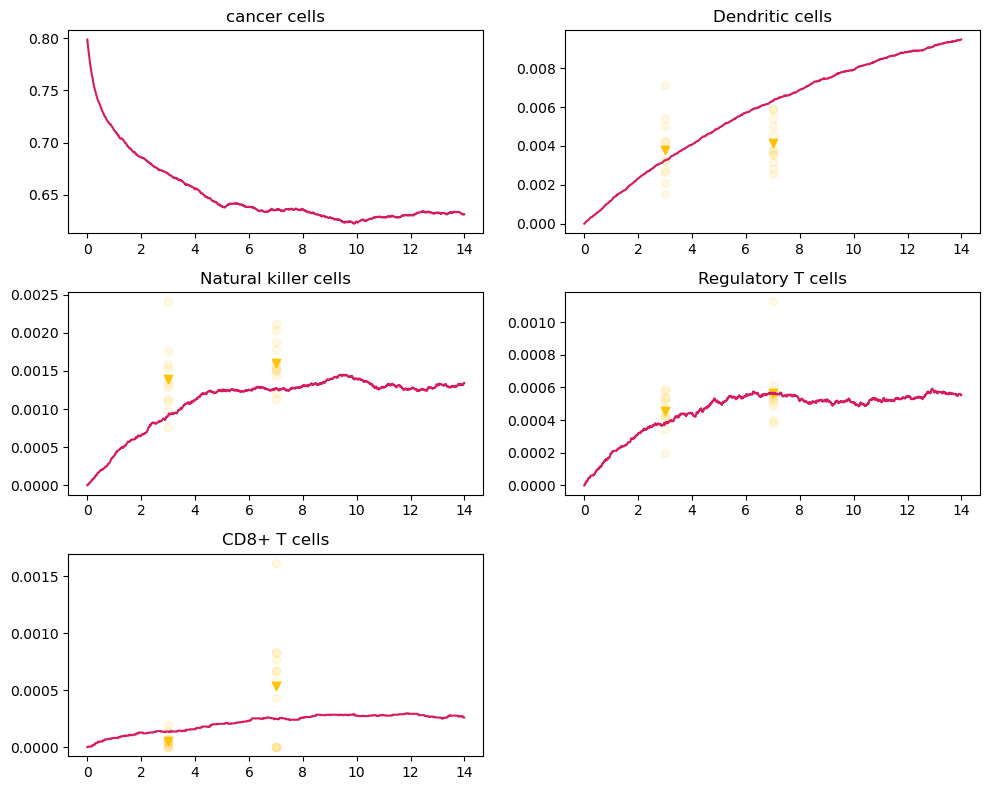

In [120]:

# simulate
t_abm, y_abm = run_abm_bestmodel(grid_size, steps, p, dt)
total_sites = grid_size**2 
# plot
fig, ax = plt.subplots(3, 2, figsize=(10, 8))

# scatter data
def get_scatter(df, col):
    times = df_T11_ICI['Timepoint'].map({'day3': 3.0, 'day7': 7.0}).values
    vals = df_T11_ICI[col].values
    # 'v' marker means 
    m3 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day3'][col].mean()
    m7 = df_T11_ICI[df_T11_ICI['Timepoint'] == 'day7'][col].mean()
    return times, vals, [3.0, 7.0], [m3, m7]

# cancer
ax[0,0].plot(y_abm['Time'], y_abm['Cancer'], color=c1)
ax[0,0].set_title('cancer cells')

# dendritic
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Dendritic_quanTIseq")
ax[0,1].plot(y_abm['Time'], y_abm['Dendritic'], color=c1)
ax[0,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[0,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[0,1].set_title('Dendritic cells')

# NK
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "NK_quanTIseq")
ax[1,0].plot(y_abm['Time'], y_abm['NK'], color=c1)
ax[1,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,0].set_title('Natural killer cells')

# Tregs
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "Tregs_quanTIseq")
ax[1,1].plot(y_abm['Time'], y_abm['Tregs'], color=c1)
ax[1,1].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[1,1].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[1,1].set_title('Regulatory T cells')

# CD8
t_scat, v_scat, t_means, v_means = get_scatter(df_T11_ICI, "T.CD8_quanTIseq")
ax[2,0].plot(y_abm['Time'], y_abm['T8'], color=c1)
ax[2,0].scatter(t_scat, v_scat, alpha=0.1, color=c3)
ax[2,0].scatter(t_means, v_means, alpha=1.0, marker='v', color=c3)
ax[2,0].set_title('CD8+ T cells')

# extra plot
ax[2,1].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
# SET THE TUMOUR CLUSTER SIZE TO BE 0.5 DIAMETER COMPARED TO THE 2CM BY 2CM SAMPLE WHICH IS WHAT THE GRID IS SIMULATING 
# SO IF THE GRID IS 100 BY 100 THEN THE TUMOUR SHOULD TAKE UP AROUND 25 BY 25 

In [123]:

def run_abm_solid_mass(grid_size, steps, p, dt):
    grids = np.zeros((5, grid_size, grid_size))
    
    # 1. CALCULATE SCALE
    # Total grid diameter = 2cm. Center of grid is (mid, mid).
    mid = grid_size / 2
    # The cancer blob diameter is 0.5cm, which is 1/4 of the total grid diameter (2cm).
    # Therefore, the radius of the cancer blob in grid units is:
    cancer_radius_grid = (0.5 / 2.0) * (grid_size / 2.0) 
    
    # 2. CREATE COORDINATE MESH
    y, x = np.ogrid[:grid_size, :grid_size]
    dist_from_center = np.sqrt((x - mid)**2 + (y - mid)**2)
    
    # 3. DEFINE SEEDING MASK
    # Only cells within the 0.5cm diameter circle are eligible
    seed_mask = dist_from_center <= cancer_radius_grid
    
    # 4. INITIAL SEEDING (80% coverage within that specific mask)
    random_roll = np.random.choice([0, 1], size=(grid_size, grid_size), p=[1-p['C_init'], p['C_init']])
    grids[0] = np.where(seed_mask, random_roll, 0)
    
    grid_history = []
  
    # Moore neighborhood (8 neighbors)
    kernel = np.array([[1, 1, 1], [1, 0, 1], [1, 1, 1]])

    for step in range(steps):
        # 1. ANALYZE LOCAL DENSITY
        cancer_neighbors = convolve2d(grids[0], kernel, mode='same')
        treg_neighbors = convolve2d(grids[3], kernel, mode='same')

        # 2. SOLID TUMOR GROWTH RULES
        # A: Growth only at the boundary (must have at least 1 neighbor)
        # B: Growth probability is high to ensure a dense pack
        can_grow = (grids[0] == 0) & (cancer_neighbors >= 1)
        # We use a non-linear boost: the more neighbors, the more likely to fill gaps
        growth_p = p['lambda_C'] * (cancer_neighbors / 3) * dt 
        grids[0][can_grow & (np.random.rand(grid_size, grid_size) < growth_p)] = 1

        # 3. HIGH ADHESION (The "Cleaning" Rule)
        # If a cell has 0 neighbors, it's a 'stray' and dies immediately
        is_stray = (grids[0] == 1) & (cancer_neighbors == 0)
        grids[0][is_stray] = 0

        # 4. NECROTIC CORE (Internal pressure)
        is_buried = (grids[0] == 1) & (cancer_neighbors == 8)
        # Low probability (0.01) keeps the core 'meaty' but eventually dead
        grids[0][is_buried & (np.random.rand(grid_size, grid_size) < 0.01 * dt)] = 0

        # 5. SHIELDED KILLING
        C, D, N, Tr, T8 = np.sum(grids, axis=(1, 2)) / (grid_size**2)
        #shield_effect = 1.0 / (1.0 + p.get('shield_strength', 5.0) * treg_neighbors)
        kill_p = ((((p['lambda_C']*C*C)/p['C_M']) + p['eta_8']*T8 + p['eta_N']*N + p['d_C']) * dt) 
        
        # Immune cells can only kill if they are touching the cancer
        at_edge = (grids[0] == 1) & (cancer_neighbors < 8)
        grids[0][at_edge & (np.random.rand(grid_size, grid_size) < kill_p)] = 0
        # dendritic 
        prob_D = (p['lambda_DC_comb'] * C / (C + p['K_C'])) * dt
        death_D = p['d_D'] * dt
        grids[1][(np.random.rand(grid_size, grid_size) < prob_D)] = 1
        grids[1][(grids[1] == 1) & (np.random.rand(grid_size, grid_size) < death_D)] = 0

        # NK
        prob_N = (p['sigma_N'] + (p['a_C']*N*C)/(1 + C/p['beta_1'] + N/p['beta_2'])) * dt
        death_N =  (p['d_N'] + p['gamma_N']*Tr)*dt
        grids[2][(np.random.rand(grid_size, grid_size) < prob_N)] = 1
        grids[2][(grids[2] == 1) & (np.random.rand(grid_size, grid_size) < death_N)] = 0

        # T regs 
        prob_Tr = (p['lambda_Tr_comb'] * C / (p['K_C'] + C)) * dt
        death_Tr = p['d_Tr']*dt
        grids[3][(np.random.rand(grid_size, grid_size) < prob_Tr)] = 1
        grids[3][(grids[3] == 1) & (np.random.rand(grid_size, grid_size) < death_Tr)] = 0

        # CD8+ 
        prob_T8 = (p['lambda_T8_comb'] * D / (p['K_D'] + D) / (1 + Tr/p['K_Tr'])) * dt
        death_T8 = p['d_T8']*dt
        grids[4][(np.random.rand(grid_size, grid_size) < prob_T8)] = 1
        grids[4][(grids[4] == 1) & (np.random.rand(grid_size, grid_size) < death_T8)] = 0
        
        # 6. MOVEMENT & HISTORY
        # (Include the chemotaxis movement logic here as in the previous functions)
        
        signal = gaussian_filter(grids[0], sigma=4.0)
        # Move NK (2), T-Regs (3), and T8 (4)
        for layer_idx in [2, 3, 4]:
            if np.sum(grids[layer_idx]) > 0:
                grad_y, grad_x = np.gradient(signal)
                # T-Regs (3) are even more attracted to the signal (higher p_move)
                p_move = 0.5 if layer_idx == 3 else 0.2 
                
                move_mask = (grids[layer_idx] == 1) & (np.random.rand(grid_size, grid_size) < p_move)
                y_idx, x_idx = np.where(move_mask)
        if step % 5 == 0:
            viz_frame = np.zeros((grid_size, grid_size))
            viz_frame[grids[3] == 1] = 2 # Purple T-Reg Shield
            viz_frame[grids[4] == 1] = 4 # Blue CD8+
            viz_frame[grids[0] == 1] = 5 # Red Solid Cancer
            grid_history.append(viz_frame.copy())

    return grid_history

In [126]:
# 40 BY 40 PIXELS BUT AT 80% SATURATION 
grid_size = 100 
history_data = run_abm_solid_mass(grid_size, steps, p, dt)

save_abm_animation(history_data, "CancerSAMPLE_MODEL1.mp4")

Saving to CancerSAMPLE_MODEL1.mp4...
Save successful.
